# **Imports**

In [ ]:
from traintestsplits_utils import *
from utils import *

import os
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns


# **Setup**

In [ ]:
#######################################
# Setup Directories and Parameters
#######################################

# directory to save split selections
split_dir = r'../models/splits'
if not os.path.isdir(split_dir):
    os.makedirs(split_dir)

# list of directories containing in-domain & cross-domain patches (GeoJSONs & areas or labels)
indomain_dirs = [r'../data/warren']
crossdomain_dirs = [r'../data/howevalley', r'../data/sonora']

# parameters for split selection
test_size = 1536
val_size = 768

# seeding...
patch_seed = 111        # used for patch selection RNG
set_seed(patch_seed)    # sets global python & numpy RNGs


# **Train, Validation, Test Splits**

## *In-domain (Warren County)*

In [ ]:
############################
# Select In-domain Splits
############################

# list of paths to in-domain patch GeoJSONs
indomain_patch_paths = [glob.glob(os.path.join(d, '*patches*.geojson'))[0] for d in indomain_dirs]


##### read patches GeoJSONs into single geodataframe
gdf_list = [gpd.read_file(p) for p in indomain_patch_paths]
gdf = pd.concat(gdf_list, ignore_index=True)


##### select test split & all remaining non-overlapping patches
gdf_test, gdf_remaining = select_indpendent_patches(gdf, test_size, seed=patch_seed)


##### select validation split & non-overlapping training split from remaining (above)
gdf_val, gdf_train = select_indpendent_patches(gdf_remaining, val_size, seed=patch_seed)


##### save training, validation, & testing patches...
gdf_train.to_file(f"{split_dir}/indomain_train.geojson", driver='GeoJSON')
gdf_val.to_file(f"{split_dir}/indomain_val.geojson", driver='GeoJSON')
gdf_test.to_file(f"{split_dir}/indomain_test.geojson", driver='GeoJSON')

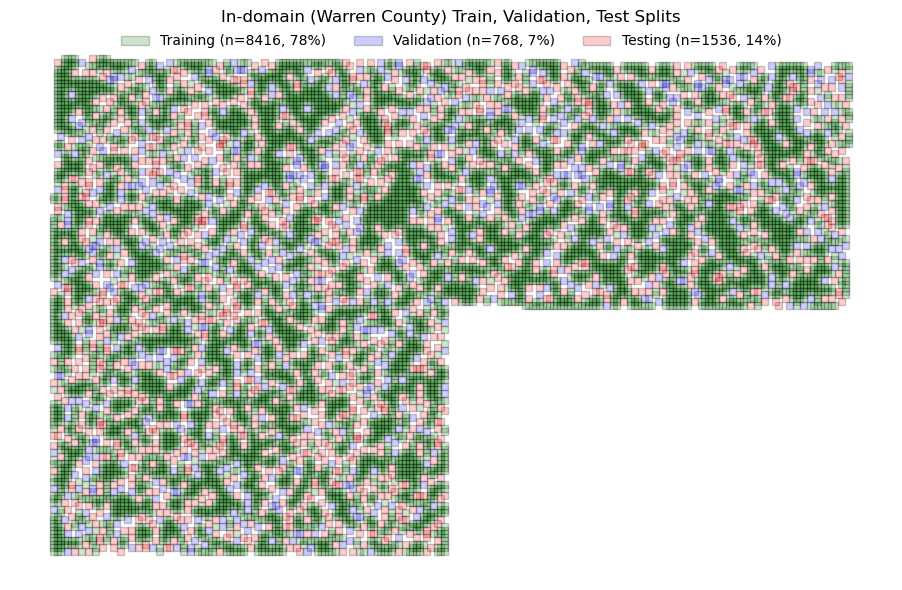

In [ ]:
#############################
# Visualize Selected Patches
#############################

fig, ax = plt.subplots(figsize=(10,6))


##### plot patch splits...
gdf_train.plot(ax=ax, facecolor='green', edgecolor='k', linewidth=1, alpha=0.2, label='Training')
gdf_val.plot(ax=ax, facecolor='blue', edgecolor='k', linewidth=1, alpha=0.2, label='Validation')
gdf_test.plot(ax=ax, facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label='Testing')


##### legend...
# count information
total_patches = len(gdf_train) + len(gdf_val) + len(gdf_test)
train_percent = len(gdf_train) / total_patches * 100
val_percent = len(gdf_val) / total_patches * 100
test_percent = len(gdf_test) / total_patches * 100

# legend labels
train_subtitle = f"Training (n={len(gdf_train)}, {int(train_percent)}%)"
val_subtitle = f"Validation (n={len(gdf_val)}, {int(val_percent)}%)"
test_subtitle = f"Testing (n={len(gdf_test)}, {int(test_percent)}%)"

# legend patches
train_patch = Patch(facecolor='green', edgecolor='k', linewidth=1, alpha=0.2, label=train_subtitle)
val_patch = Patch(facecolor='blue', edgecolor='k', linewidth=1, alpha=0.2, label=val_subtitle)
test_patch = Patch(facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label=test_subtitle)
ax.legend(handles=[train_patch, val_patch, test_patch], loc='center', bbox_to_anchor=(0.5, 0.98), frameon=False, ncols=3)


##### title, axis, and save...
ax.set_title('In-domain (Warren County) Train, Validation, Test Splits')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{split_dir}/indomain_splits.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## *Cross-domain (Hardin County)*

In [ ]:
##############################
# Test Set from Hardin County
##############################

# list of paths to cross-domain patch GeoJSONs
crossdomain_patch_paths = [glob.glob(os.path.join(d, '*patches*.geojson'))[0] for d in crossdomain_dirs]


##### read patches GeoJSONs into single geodataframe
gdf_list = [gpd.read_file(p) for p in crossdomain_patch_paths]
gdf = pd.concat(gdf_list, ignore_index=True)


##### select test set
gdf_test_cross, _ = select_indpendent_patches(gdf, test_size, seed=patch_seed)


##### save training, validation, & testing patches
gdf_test_cross.to_file(f"{split_dir}/crossdomain_test.geojson", driver='GeoJSON')

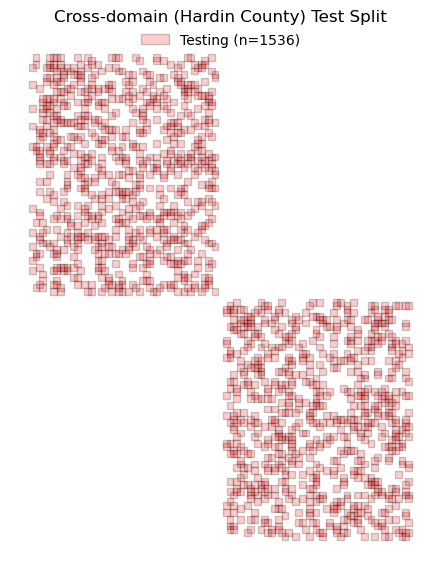

In [ ]:
#############################
# Visualize Selected Patches
#############################

fig, ax = plt.subplots(figsize=(8,6))

##### plot cross-domain test split...
gdf_test_cross.plot(ax=ax, facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label='Testing')

##### legend...
test_subtitle = f"Testing (n={len(gdf_test_cross)})"                                              # legend label
test_patch = Patch(facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label=test_subtitle)   # legend patch
ax.legend(handles=[test_patch], loc='center', bbox_to_anchor=(0.5, 0.98), frameon=False)          # add legend to plot

##### title, axis, and save...
ax.set_title('Cross-domain (Hardin County) Test Split')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{split_dir}/crossdomain_split.jpg")
plt.show()

# **Class Distributions**

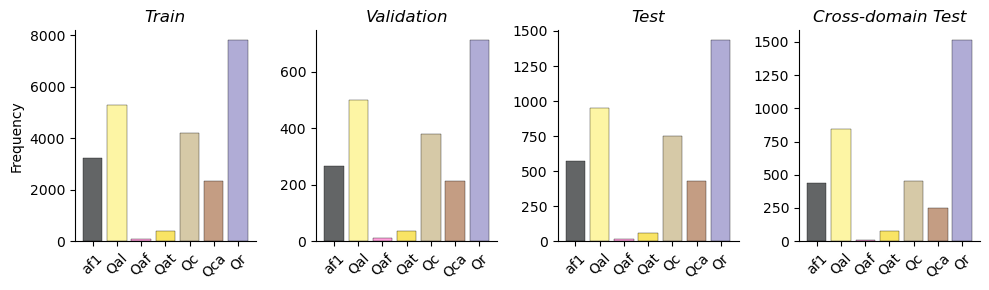

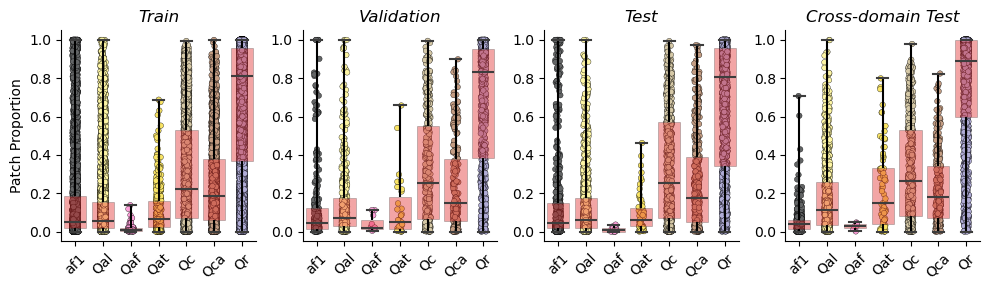

In [79]:
#########################
# Plot Bar Distributions
#########################

# paths to split GeoJSONs
split_paths = [f"{split_dir}/indomain_train.geojson", 
               f"{split_dir}/indomain_val.geojson", 
               f"{split_dir}/indomain_test.geojson", 
               f"{split_dir}/crossdomain_test.geojson"]


##### get in-domain & cross-domain patch areas...
# in-domain...
indomain_area_paths = [glob.glob(os.path.join(d, '*areas.csv'))[0] for d in indomain_dirs]
indomain_area_list = [pd.read_csv(p) for p in indomain_area_paths]
indomain_area = pd.concat(indomain_area_list, ignore_index=True)
indomain_area.set_index('patch_id', drop=True, inplace=True)

# cross-domain...
crossdomain_area_paths = [glob.glob(os.path.join(d, '*areas.csv'))[0] for d in crossdomain_dirs]
crossdomain_area_list = [pd.read_csv(p) for p in crossdomain_area_paths]
crossdomain_area = pd.concat(crossdomain_area_list, ignore_index=True)
crossdomain_area.set_index('patch_id', drop=True, inplace=True)


##### plot class distributions...
fig1, ax1 = plt.subplots(ncols=4, figsize=(10,3))   # class counts
fig2, ax2 = plt.subplots(ncols=4, figsize=(10,3))   # class area per patch proportions

# iterate over splits...
for idx, split in enumerate(split_paths):

    # get split patch IDs
    split_ids = gpd.read_file(split, ignore_geometry=True)['patch_id']     

    # select areas for split...
    if 'indomain' in split:
        df = indomain_area.loc[split_ids]
    else:
        df = crossdomain_area.loc[split_ids]
    
    x = df.columns                                        # define classes
    colors = [map_colors[geo_unit] for geo_unit in x]     # define class colors from global dictionary
    mask = df[x] > 0                                      # define mask to select relevant patches for counts & areas
    counts = (mask).sum(axis=0)                           # get class counts
    areas = df[mask]                                      # get class areas

    # plot distributions...
    ax1[idx].bar(x=x, height=counts.values, lw=0.25, edgecolor='k', facecolor=colors)
    sns.stripplot(data=areas, ax=ax2[idx], jitter=True, palette=colors, edgecolor='k', linewidth=0.25, size=4, zorder=1)
    sns.boxplot(data=areas, ax=ax2[idx], color='red', whis=(0,100), linewidth=1.5, zorder=2, 
                boxprops={'alpha':0.4, 'lw':0.5}, whiskerprops={'lw':1.5, 'color':'k'}, capprops={'lw':1.5})


##### style plot & save...
for idx, split in enumerate(['Train', 'Validation', 'Test', 'Cross-domain Test']):
    ax1[idx].set_title(split, style='italic')
    ax1[idx].spines['top'].set_visible(False)
    ax1[idx].spines['right'].set_visible(False)
    ax1[idx].set_xticks(ax[idx].get_xticks())
    ax1[idx].set_xticklabels(ax[idx].get_xticklabels(), rotation=45)
ax1[0].set_ylabel('Frequency')

for idx, split in enumerate(['Train', 'Validation', 'Test', 'Cross-domain Test']):
    ax2[idx].set_title(split, style='italic')
    ax2[idx].spines['top'].set_visible(False)
    ax2[idx].spines['right'].set_visible(False)
    ax2[idx].set_xticks(ax[idx].get_xticks())
    ax2[idx].set_xticklabels(ax[idx].get_xticklabels(), rotation=45)
ax2[0].set_ylabel('Patch Proportion')

fig1.tight_layout()
fig2.tight_layout()

fig1.savefig(f"{split_dir}/split_counts.png", dpi=300, bbox_inches='tight', pad_inches=0)
fig2.savefig(f"{split_dir}/split_proportions.png", dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()